In [4]:
import db_utils
import sqlite3
import pandas as pd

# Connect to 
conn = sqlite3.connect('main.db')
coins_with_social = pd.read_sql_query("SELECT coin_address FROM coin_socials_table", conn)
# turn into set
coins_with_social = set(coins_with_social['coin_address'])
print(len(coins_with_social))

all_coins = pd.read_sql_query("SELECT coin_address FROM coin_table", conn)
# turn into set
all_coins = set(all_coins['coin_address'])
print(len(all_coins))

# find coins that are in all_coins but not in coins_with_social
coins_without_social = all_coins - coins_with_social
print(len(coins_without_social))


2025
4134
2110


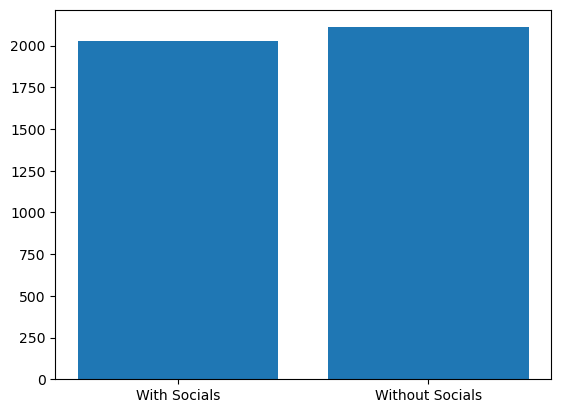

In [5]:
# initial bar plot of coins with vs without socials
import matplotlib.pyplot as plt

plt.bar(['With Socials', 'Without Socials'], [len(coins_with_social), len(coins_without_social)])
plt.show()



In [ ]:
import requests
import time
import re
from collections.abc import Mapping, Sequence
from requests import exceptions as req_exc

from tqdm import tqdm

def get_coin_data(coin_address: str):
    url = f"https://api.rugcheck.xyz/v1/tokens/{coin_address}/report"
    resp = requests.get(url)
    resp.raise_for_status()
    time.sleep(2)
    data_dict = resp.json()
    return data_dict

TWITTER_RE  = re.compile(r"https?://(?:x\.com|twitter\.com)/[^\s\"'<>]+")
TELEGRAM_RE = re.compile(r"(?:https?://)?t\.me/[^\s\"'<>]+")
URL_RE      = re.compile(r"https?://[^\s\"'<>]+")

def extract_socials(data, _seen=None):
    """
    Traverse *data* (any nested mix of dict/list/tuple/set/str/…) and return
    {'twitter': [...], 'telegram': [...], 'website': [...]}.

    All lists preserve first-seen order and contain no duplicates.
    """
    if _seen is None:                   # top-level call: init empty ordered sets
        _seen = {"twitter": dict.fromkeys([]),
                 "telegram": dict.fromkeys([]),
                 "website": dict.fromkeys([])}

    if isinstance(data, str):
        # Grab every HTTP(S) URL first …
        for url in URL_RE.findall(data):
            if TWITTER_RE.fullmatch(url):
                _seen["twitter"].setdefault(url)
            elif TELEGRAM_RE.fullmatch(url):
                _seen["telegram"].setdefault(url)
            else:
                _seen["website"].setdefault(url)

        # … then capture *bare* “t.me/…” that lacked http(s)://
        for url in TELEGRAM_RE.findall(data):
            if not url.startswith("http"):
                url = f"https://{url}"   # normalise
            _seen["telegram"].setdefault(url)

    elif isinstance(data, Mapping):
        for v in data.values():
            extract_socials(v, _seen)

    elif isinstance(data, Sequence) and not isinstance(data, (str, bytes)):
        for item in data:
            extract_socials(item, _seen)

    # convert ordered sets → lists on exit from the original call
    if _seen is not None and all(isinstance(v, dict) for v in _seen.values()):
        return {k: list(v) for k, v in _seen.items()}


coin_dict = {}
for coin in tqdm(coins_without_social):
    uri = None
    try:
        data = get_coin_data(coin)
        uri = data["tokenMeta"]["uri"]
    except Exception as e:
        print(f"Error getting coin data for {coin}: {e}")
        continue

    # check if uri is valid
    if uri is None or uri == "":
        coin_dict[coin] = "no uri"
        continue

    uri_dict = None
    try:
        uri_data = requests.get(uri)
        uri_data.raise_for_status()
        time.sleep(2)
        uri_dict = uri_data.json()
    except Exception as e:
        pass

    # check if uri_dict is valid
    if uri_dict is None:
        coin_dict[coin] = "uri failed"
        continue


    twitter = None
    telegram = None
    website = None
    createdOn = None
    createdOn_site = None

    if "extensions" in uri_dict:
        extensions = uri_dict["extensions"]
        if "twitter" in extensions:
            twitter = extensions["twitter"]
        if "telegram" in extensions:
            telegram = extensions["telegram"]
        if "website" in extensions:
            website = extensions["website"]
        if "createdOn" in extensions:
            createdOn = extensions["createdOn"]
        if "creator" in extensions:
            if "site" in extensions["creator"]:
                createdOn_site = extensions["creator"]["site"]
    else:
        extracted_urls = extract_socials(uri_dict)
        if len(extracted_urls["twitter"]) > 0:
            twitter = extracted_urls["twitter"][0]
        if len(extracted_urls["telegram"]) > 0:
            telegram = extracted_urls["telegram"][0]

    coin_dict[coin] = {
        "twitter": twitter,
        "telegram": telegram,
        "website": website,
        "createdOn": createdOn,
        "createdOn_site": createdOn_site
    }    

In [22]:
df = pd.read_sql_query("SELECT * FROM coin_socials_table", conn)
df.head()

,coin_address,twitter,telegram,website,createdOn,createdOn_site
0,D8qMn1hGsv2JXmbmF4eT1X1B7RMqcn4Xq9p37o352ZrQ,https://x.com/morlogeMagazine,https://t.me/TURBOMemeOfficial,https://t.me/TURBOMemeOfficial,None,https://tools.smithii.io/token-creator/solana
1,9fea2FVFHFrF4ETtFRiHNVFDW7taaQb1TqfdMrWDhGzV,,,https://knowyourmeme.com/memes/poggers,None,None
2,6yi18Db9RMtx7kFJ9S8fVUJeK5RiyqnFQEZEWfuiCFqZ,https://twitter.com/ERC20Trolls,https://t.me/InfiniteUSDTGlitch,https://x.com/pumpdotfun,None,None
3,79jKG2XvTzDMdFZzbaJGvzZjLkV9zp9Sk34zrHdpump,https://x.com/YE,None,None,None,None
4,7ajXnZAQVHcVrdNqhRZTM2zK2cfvASycEebpv1yjXen7,https://x.com/REID,None,None,None,None


In [23]:
df.shape

(2025, 6)

In [24]:
for coin in coin_dict.keys():
    if coin_dict[coin] == "no uri" or coin_dict[coin] == "uri failed":      
        entry = {
            "coin_address": coin,
            "twitter": None,
            "telegram": None,
            "website": None,
            "createdOn": None,
            "createdOn_site": None,
        }
    else:
        entry = coin_dict[coin]
        entry["coin_address"] = coin

    # add entry to df
    df = pd.concat([df, pd.DataFrame([entry])], ignore_index=True)

df.shape


(4019, 6)

In [25]:
# checkpoint
df.to_csv("data/post/socials.csv", index=False)

In [107]:
df = pd.read_csv("data/post/socials.csv")
df.head()

,coin_address,twitter,telegram,website,createdOn,createdOn_site
0,D8qMn1hGsv2JXmbmF4eT1X1B7RMqcn4Xq9p37o352ZrQ,https://x.com/morlogeMagazine,https://t.me/TURBOMemeOfficial,https://t.me/TURBOMemeOfficial,NaN,https://tools.smithii.io/token-creator/solana
1,9fea2FVFHFrF4ETtFRiHNVFDW7taaQb1TqfdMrWDhGzV,NaN,NaN,https://knowyourmeme.com/memes/poggers,NaN,NaN
2,6yi18Db9RMtx7kFJ9S8fVUJeK5RiyqnFQEZEWfuiCFqZ,https://twitter.com/ERC20Trolls,https://t.me/InfiniteUSDTGlitch,https://x.com/pumpdotfun,NaN,NaN
3,79jKG2XvTzDMdFZzbaJGvzZjLkV9zp9Sk34zrHdpump,https://x.com/YE,NaN,NaN,NaN,NaN
4,7ajXnZAQVHcVrdNqhRZTM2zK2cfvASycEebpv1yjXen7,https://x.com/REID,NaN,NaN,NaN,NaN


In [108]:
def update_twitter_url(twitter_url):
    if twitter_url is None or twitter_url == "":
        return None
    
    import numpy as np
    try:
        if np.isnan(twitter_url):
            return None
    except:
        pass

    # replace twitter.com with x.com
    twitter_url = twitter_url.replace("twitter.com", "x.com")  
    if not twitter_url.startswith("https://x.com/"):
        twitter_url = "https://x.com/" + twitter_url

    # if the twitter url has a /status/
    # remove the /status/ and everything after it
    if "/status/" in twitter_url:
        twitter_url = twitter_url.split("/status/")[0]

    if "/search" in twitter_url:
        return None

    if "?" in twitter_url:
        twitter_url = twitter_url.split("?")[0]

    if "/communities/" in twitter_url:
        return None
    
    if "/intent/" in twitter_url:
        return None
    
    if "/https://" in twitter_url:
        return None
    
    return twitter_url

# apply the update_twitter_url function to the twitter column
df["twitter"] = df["twitter"].apply(update_twitter_url)
df.head()

,coin_address,twitter,telegram,website,createdOn,createdOn_site
0,D8qMn1hGsv2JXmbmF4eT1X1B7RMqcn4Xq9p37o352ZrQ,https://x.com/morlogeMagazine,https://t.me/TURBOMemeOfficial,https://t.me/TURBOMemeOfficial,NaN,https://tools.smithii.io/token-creator/solana
1,9fea2FVFHFrF4ETtFRiHNVFDW7taaQb1TqfdMrWDhGzV,None,NaN,https://knowyourmeme.com/memes/poggers,NaN,NaN
2,6yi18Db9RMtx7kFJ9S8fVUJeK5RiyqnFQEZEWfuiCFqZ,https://x.com/ERC20Trolls,https://t.me/InfiniteUSDTGlitch,https://x.com/pumpdotfun,NaN,NaN
3,79jKG2XvTzDMdFZzbaJGvzZjLkV9zp9Sk34zrHdpump,https://x.com/YE,NaN,NaN,NaN,NaN
4,7ajXnZAQVHcVrdNqhRZTM2zK2cfvASycEebpv1yjXen7,https://x.com/REID,NaN,NaN,NaN,NaN


In [109]:
# group by twitter handle discard telegram	website	createdOn	createdOn_site, and keep count of the number of coins for each twitter handle, label it twitter_count
twitter_grouped = df.groupby('twitter')['coin_address'].count().reset_index(name='twitter_count')
# sort by count
twitter_grouped = twitter_grouped.sort_values(by='twitter_count', ascending=False)
# Drop rows with no twitter handle
twitter_grouped = twitter_grouped[twitter_grouped['twitter'] != ""]
# add a processed column that defaults to 0
twitter_grouped['processed'] = 0

# use the twitter handle as the x axis label
twitter_grouped.head()

,twitter,twitter_count,processed
683,https://x.com/elonmusk,31,0
50,https://x.com/BarronMemeParty,30,0
265,https://x.com/MR BEAST,23,0
531,https://x.com/Wizard,22,0
538,https://x.com/YE,22,0


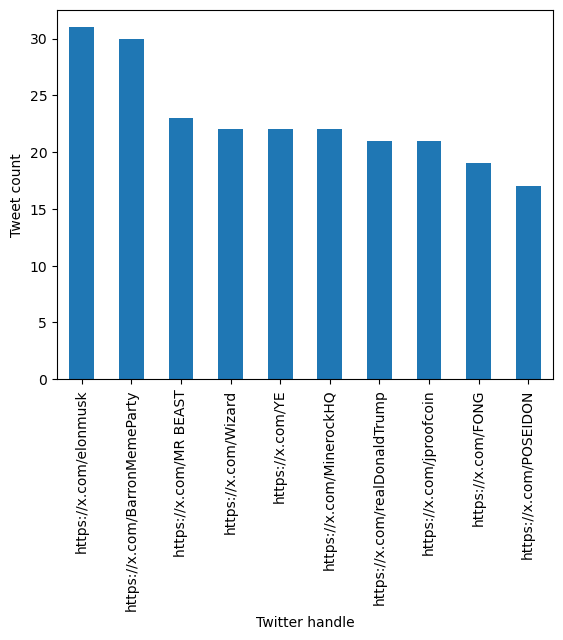

In [110]:
(
    twitter_grouped.head(10)          # first 10 rows
    .plot(                            # plot a bar chart
        kind="bar",
        x="twitter",           # use handle for the x-axis
        y="twitter_count",            # bar heights
        legend=False, 
    )
)
plt.xlabel("Twitter handle")
plt.ylabel("Tweet count")
plt.show()

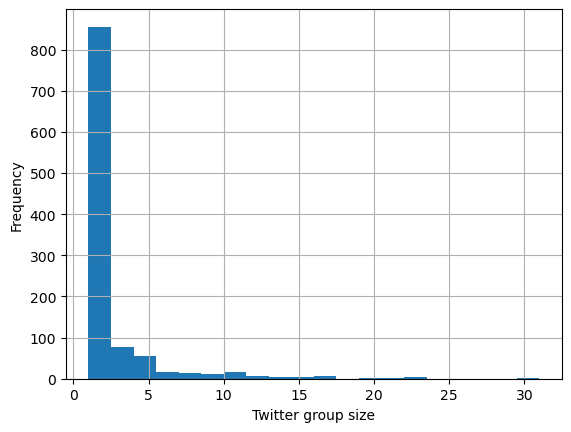

In [111]:
# do a histogram of the twitter_count group by 10
twitter_grouped["twitter_count"].hist(bins=20)
plt.xlabel("Twitter group size")
plt.ylabel("Frequency")
plt.show()

In [102]:
df.to_csv("data/post/socials_clean_1.csv", index=False)
twitter_grouped.to_csv("data/post/twitter_grouped.csv", index=False)

In [104]:
import db_utils
import sqlite3
import pandas as pd

# Connect to 
conn = sqlite3.connect('main.db')
tweets = pd.read_sql_query("SELECT * FROM tweets_table WHERE coin_address != 'unknown'", conn)
tweets.head()

,observation_id,coin_address,pair_address,tweet_id,tweet_created_at,tweet_text,tweet_sentiment_label,tweet_sentiment_label_prob,tweet_engagement_score,user_id,username,user_description,user_followers_count,user_following_count,verified,is_blue_verified,user_created_at,user_last_updated
0,1,E8CGkGTkVPR41QgbrMyYBMzYWEx5Kajw51x7njSPtfYv,CTgm5FpjkKxg7tv63fGqj2ssJjjShSJ1QsYGXh6NqJAz,1914575339789148558,1745305306,🚨 Trending 🚨\n\n📈 FDV 5MIN 💹 +$20.8K(+31.53%) ...,positive,0.999981,1.659133,4019075112,ノリノスケ@mzdao,you even if you have any more bad manners he w...,274,1139,0,0,1445822118,1745385530
1,2,2Hmkjw9RGSJiMQboj1ULbbWt77xdGvVNKMj6QRCbSbyW,7eErXEaWzJe65AMcBnc6sZ8R7KX7zBpBCaAdcPDBCxN4,1914578022881247694,1745305946,Detect PAID DEXScreener: $SOLUNA 👇\n ...,neutral,0.999959,2.425256,1806913801754963968,Dex signals,Check Paid Dex👇\n https://t.co/Pvons...,7073,32,0,1,1719636806,1745385552
2,3,GsqARQyjNXQxw4R4ASFbVeLu8ZPWBFHqre3YimheBVdD,FC2Jmjse7LUmPYXf7iRVSwCRKi1A5NymJVN9qhxMoK3t,1914583371499626848,1745307221,🤖 FDV Alert 🤖\n\n🌠 - $POG\n💪 - GsqARQyjNXQxw4R...,neutral,0.999875,1.733796,1540809779161219072,TheasGonzalez,Real girls arent perfect Perfect girls arent r...,635,1405,0,0,1656192659,1745386178
3,4,55MLQqMRZ9EKHqcswNxrkhfbt1xPJW4xujRSKTbXUuhd,FHTnZVPX1dGePM9VzgBHV2nkirrkinRnDD6F1Arcj2Am,1914584145285841035,1745307406,📣 Signal &amp; ⚡QUICK TRADE⚡ 👉👉 https://t.co/2...,positive,0.999918,1.830620,1859819270,Vrianfang,Japan Travel Guide | CNN Travel\ndiscord:Jayfa...,297,1191,0,0,1379057624,1745386241
4,5,WVzYFs3mrMRpJ7VMvCApTXG3ZTrfPqkdGBVfR1hpump,FV11DKG7pPDYT1pdhZCRRp2p6ZBSgfCw3GVDAXYZwGVD,1914589022137278884,1745308568,🚨 Trending 🚨\n\n📈 FDV 5MIN 💹 +$1M(+3256.9%) \n...,positive,0.999976,2.028513,1542449247424892928,ClaraasSloan,Whatever is worth doing at all is worth B5A6Y4...,950,1191,0,0,1656583539,1745386344


In [106]:
# save to csv
tweets.to_csv("data/post/tweets.csv", index=False)